# AG-HYPOPT · Trial 38

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirty-seven trials are registered; cell 2 reports `phase = trials` (37/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074), with trial_30 (0.1083) second. Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- best (all 0 div): trial_21 0.1074 (0.138), trial_30 0.1083 (0.134), trial_22 0.1095 (0.137), trial_32 0.1097 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_31 0.1106 (0.131), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_36 0.1117 (0.134), trial_33 0.1120 (0.143), trial_18 0.1121 (0.138), trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127.
- worse: trial_13 0.1132, trial_37 0.1134 (0.136, low lr_gamma), trial_05 = trial_19 0.1135, trial_07 0.1140, trial_27 0.1149 (0.194), trial_35 0.1167 (0.122), trial_06 = trial_11 0.1188, trial_02 0.1449 (0.264).
- diverging at 1nW T05 (near-optimum travel): trial_29 0.1331, trial_26 0.1368, trial_28 0.1370, trial_34 0.1380. Other diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418.

State of play: narrow single optimum at travel ~0.137-0.138 with balanced gamma knobs (`lr_gamma` ~0.40-0.49). Eight surviving samples at or below 0.112 (0.1074-0.1117). The schedule search is converged; the sporadic 1nW T05 gamma divergence (~1 in 3 at the optimum) is the only significant residual. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_38'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (37/5 trials)
ID |     ei | params
 1 | 1.0340 | {"gamma_anneal": 0.45506315202484643, "lr_gamma": 0.48334360981466384, "lr_mu": 0.1695073906686789, "mu_anneal": 0.32776674133925826}
 2 | 3.5763 | {"gamma_anneal": 0.49247145127460257, "lr_gamma": 0.46505955003313243, "lr_mu": 0.16236764817733176, "mu_anneal": 0.3471404043562288}
 3 | 3.4531 | {"gamma_anneal": 0.46309681348869813, "lr_gamma": 0.4002013259006536, "lr_mu": 0.16669635595407697, "mu_anneal": 0.3472616348484535}
 4 | 3.0751 | {"gamma_anneal": 0.5525641563001602, "lr_gamma": 0.46131898287510165, "lr_mu": 0.1631700155903393, "mu_anneal": 0.34514491061898683}
 5 | 3.6985 | {"gamma_anneal": 0.5163876009994693, "lr_gamma": 0.39573960747638715, "lr_mu": 0.15644858773580594, "mu_anneal": 0.34854510936950966}
 6 | 2.1747 | {"gamma_anneal": 0.5410772932065758, "lr_gamma": 0.46800639787899323, "lr_mu": 0.14801588945725505, "mu_anneal": 0.34360432837105054}
 7 | 0.6138 | {"gamma_anneal": 0.4802419545799786, "lr_gamma": 

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (37 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 5: **ei 3.70** — `lr_mu=0.1564`, `mu_anneal=0.3485` (travel **0.129**), `lr_gamma=0.3957`, `gamma_anneal=0.5164`.
- candidate 2: ei 3.58 — `lr_mu=0.1624`, `mu_anneal=0.3471` (travel 0.134), `lr_gamma=0.4651`, `gamma_anneal=0.4925`.
- candidate 3: ei 3.45 — `lr_mu=0.1667`, `mu_anneal=0.3473` (travel 0.138), `lr_gamma=0.4002`, `gamma_anneal=0.4631`.
- candidate 4: ei 3.08 — `lr_mu=0.1632`, `mu_anneal=0.3451` (travel 0.135), `lr_gamma=0.4613`, `gamma_anneal=0.5526`.
- candidate 8: ei 2.90 — `lr_mu=0.1680`, `mu_anneal=0.3547` (travel 0.138), `lr_gamma=0.4916`, `gamma_anneal=0.7352`.

The top candidates are all in the optimum band (travel 0.129-0.138). Candidate 5 has the highest ei at travel 0.129, with `lr_gamma=0.3957`/`gamma_anneal=0.5164` just inside the reliable gamma range. Candidates 2 and 3 are slightly more central (0.134/0.138) with close ei. Candidate 3 at travel 0.138 sits exactly on the best (trial_21's 0.138) with `lr_gamma=0.4002` - it is arguably the most on-target, just behind on ei. Given the region is fully mapped, I take the maximum-ei candidate 5; if it survives the low-count cell it should land ~0.108-0.112.

I choose candidate 5 (5 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5163876009994693, 'lr_gamma': 0.39573960747638715, 'lr_mu': 0.15644858773580594, 'mu_anneal': 0.34854510936950966}
Running  1nW Trans05 ... 

μ 9.39 -> 10.15 | γ 8.5 -> 4.27 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 42.34 | γ 8.5 -> 6.24 | NLL 5.09


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 77.46 | γ 14.1 -> 14.42 | NLL 3.61


Running 3nW Trans100 ... 

μ 175.71 -> 107.85 | γ 14.1 -> 13.85 | NLL 3.21



Total: 7.9 min


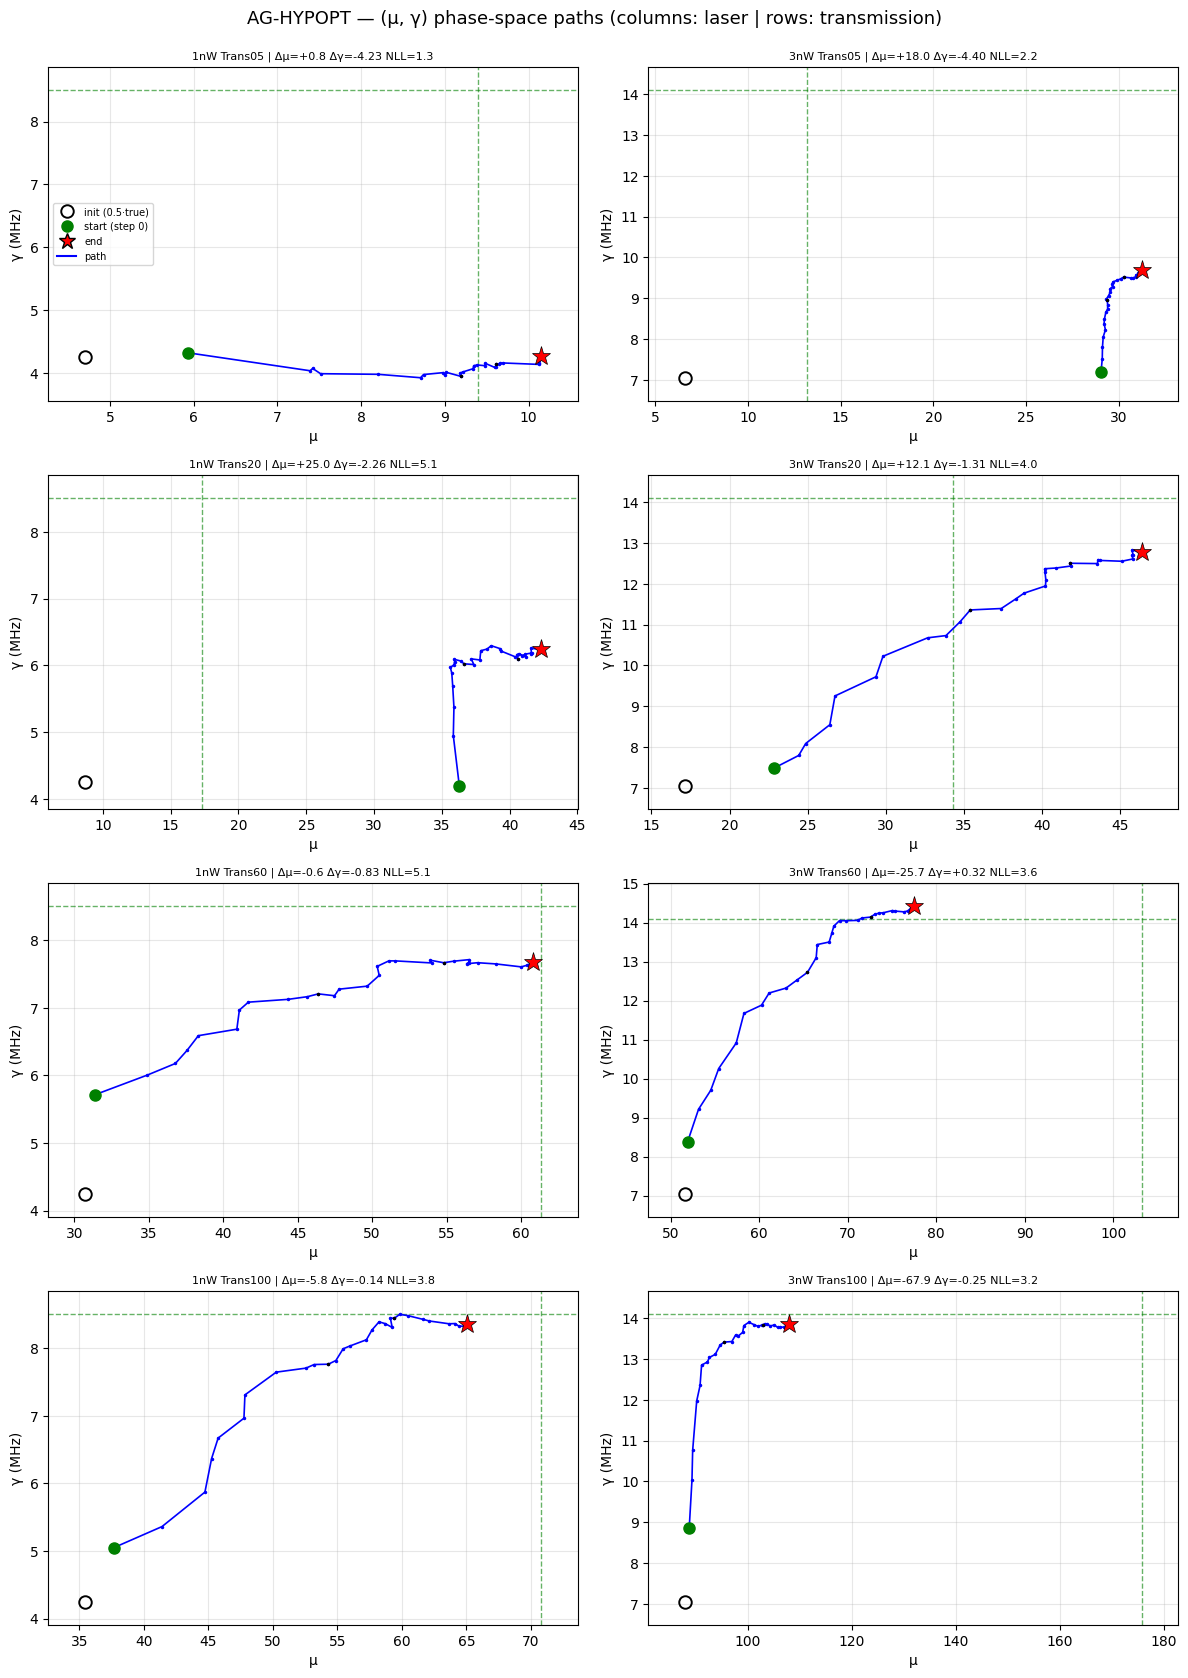

trial finished in 7.9 min
objective = 0.1128 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.15    +8.1 |     8.50    4.27   -49.8
1nW Trans20       17.32   42.34  +144.5 |     8.50    6.24   -26.6
1nW Trans60       61.37   60.78    -1.0 |     8.50    7.67    -9.7
1nW Trans100       70.82   65.03    -8.2 |     8.50    8.36    -1.6
3nW Trans05       13.20   31.23  +136.5 |    14.10    9.70   -31.2
3nW Trans20       34.28   46.37   +35.3 |    14.10   12.79    -9.3
3nW Trans60      103.20   77.46   -24.9 |    14.10   14.42    +2.3
3nW Trans100      175.71  107.85   -38.6 |    14.10   13.85    -1.8

weighted objective (T-graded, cap=1.0) = 0.1128 | diverged cells: 0
μ: RMSE 28.284 (rel 73.3%, bias -5.510) | γ: RMSE 2.372 (rel 23.3%, bias -1.637)


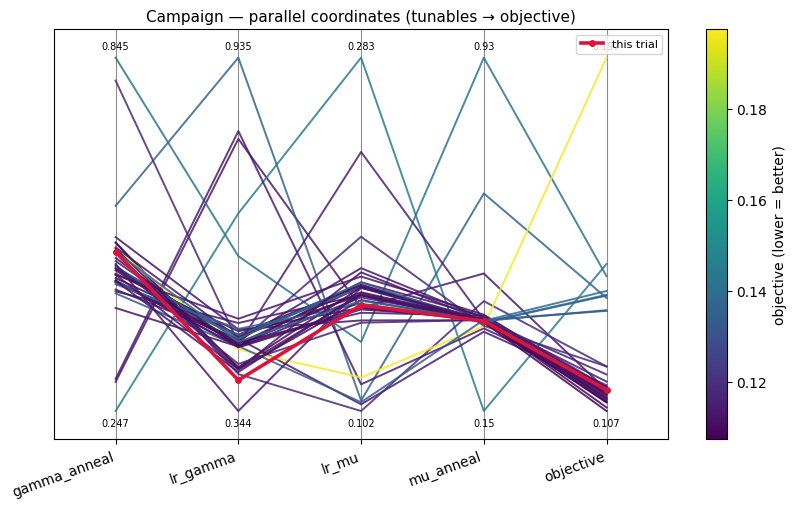

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 38 ran the highest-EI candidate (candidate 5, ei=3.70): `lr_mu=0.1564`, `mu_anneal=0.3485` (effective mu travel 0.129), `lr_gamma=0.3957`, `gamma_anneal=0.5164`. It completed in 7.9 min with objective **0.1128 +/- 0.0825** and **0 diverged cells** — mid-band. Ranking: trial_21 0.1074 < ... < trial_01 = trial_14 = trial_23 0.1127 < **trial_38 0.1128** < ...

Aggregate accuracy: **mu rel-RMSE 73.3%** (RMSE 28.28, bias -5.51); **gamma rel-RMSE 23.3%** (RMSE 2.37, bias -1.64).

Per-cell relative errors:
- **mu:** 1nW T05 +8.1%, T20 +144.5%, T60 -1.0%, T100 -8.2% | 3nW T05 +136.5%, T20 +35.3%, T60 -24.9%, T100 -38.6%.
- **gamma:** 1nW T05 -49.8%, T20 -26.6%, T60 -9.7%, T100 -1.6% | 3nW T05 -31.2%, T20 -9.3%, T60 +2.3%, T100 -1.8%.

A divergence-free optimum-band sample (travel 0.129) landing at 0.1128 — the usual story, no new behaviour. This is the ninth surviving sample at or below 0.113. The optimum's schedule level is fully characterised (~0.108-0.113) and trial_21 (0.1074) remains the best.

**Summary:** Trial 38 (lr_mu=0.1564, mu_anneal=0.3485, lr_gamma=0.3957, gamma_anneal=0.5164): objective 0.1128 +/- 0.0825 with 0 diverged cells; another divergence-free optimum sample (travel 0.129) landed mid-band, keeping the region's level at ~0.108-0.113 and trial_21 (0.1074) as best.
**Key insight:** Trial 38 is the ninth surviving sample at or below 0.113; the optimum's schedule level is fully characterised at ~0.108-0.113 and the sporadic 1nW T05 divergence remains the only significant residual.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Unchanged: converged schedule; divergence is the remaining structural issue. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 38 (lr_mu=0.1564, mu_anneal=0.3485, lr_gamma=0.3957, gamma_anneal=0.5164): objective 0.1128 +/- 0.0825 with 0 diverged cells; another divergence-free optimum sample (travel 0.129) landed mid-band, keeping the region's level at ~0.108-0.113 and trial_21 (0.1074) as best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Trial 38 is the ninth surviving sample at or below 0.113; the optimum's schedule level is fully characterised at ~0.108-0.113 and the sporadic 1nW T05 divergence remains the only significant residual"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_38 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_39.ipynb. Open it and follow its cells from the top.
